**import library and load dataset in df datframe**

In [1]:
import pandas as pd


df_metasploitable = pd.read_csv('metasploitable-2.csv')
df_OVS = pd.read_csv('OVS.csv')
df_normal = pd.read_csv('Normal_data.csv')



df = pd.concat([df_metasploitable, df_OVS, df_normal], axis=0, ignore_index=True)




**null values check**

In [29]:
df.isnull().sum()

,0
Flow ID,0
Src IP,0
Src Port,0
Dst IP,0
Dst Port,0
Protocol,0
Flow Pkts/s,0
Flow IAT Mean,0
Bwd IAT Tot,0
Bwd IAT Mean,0


**dataset info check**

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343889 entries, 0 to 343888
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Flow ID            343889 non-null  float64
 1   Src IP             343889 non-null  float64
 2   Src Port           343889 non-null  float64
 3   Dst IP             343889 non-null  float64
 4   Dst Port           343889 non-null  float64
 5   Protocol           343889 non-null  float64
 6   Flow Pkts/s        343889 non-null  float64
 7   Flow IAT Mean      343889 non-null  float64
 8   Bwd IAT Tot        343889 non-null  float64
 9   Bwd IAT Mean       343889 non-null  float64
 10  Bwd IAT Max        343889 non-null  float64
 11  Fwd Header Len     343889 non-null  float64
 12  Bwd Header Len     343889 non-null  float64
 13  Bwd Pkts/s         343889 non-null  float64
 14  Init Bwd Win Byts  343889 non-null  float64
 15  Label              343889 non-null  int64  
dtypes:

**print label counts**

In [2]:
Label_counts = df['Label'].value_counts()

print(Label_counts)

Label
Probe         98129
DDoS          73529
Normal        68424
DoS           53616
DDoS          48413
BFA            1405
Web-Attack      192
BOTNET          164
U2R              17
Name: count, dtype: int64


**print 5 values of the dataset**

In [5]:
df.head(5)

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.3.130-200.175.2.130-38694-4444-6,192.168.3.130,38694,200.175.2.130,4444,6,10/1/2020 5:02,269709,4,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,U2R
1,192.168.3.130-200.175.2.130-38693-4444-6,192.168.3.130,38693,200.175.2.130,4444,6,10/1/2020 5:02,268599,2,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,U2R
2,192.168.3.130-200.175.2.130-3632-33747-6,200.175.2.130,33747,192.168.3.130,3632,6,10/1/2020 5:02,22194,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,U2R
3,192.168.3.130-200.175.2.130-8180-38745-6,200.175.2.130,38745,192.168.3.130,8180,6,10/1/2020 1:39,9556,4,4,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BFA
4,192.168.3.130-200.175.2.130-8180-37217-6,200.175.2.130,37217,192.168.3.130,8180,6,10/1/2020 1:39,8782,4,4,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BFA


**encode object column to numeric form**

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


df['Dst IP'] = le.fit_transform(df['Dst IP'])


df['Src IP'] = le.fit_transform(df['Src IP'])

df['Flow ID'] = le.fit_transform(df['Flow ID'])


In [8]:
df = df.drop(columns=['Timestamp'])

In [11]:
df = df.dropna().reset_index(drop=True)


**encode target column to numeric form**

In [13]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()

df['Label'] = le.fit_transform(df['Label'])

# Show the mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print("Label Mapping:")
for label, encoded in label_mapping.items():
    print(f"{label} → {encoded}")


Label Mapping:
BFA → 0
BOTNET → 1
DDoS → 2
DoS → 3
Normal → 4
Probe → 5
U2R → 6
Web-Attack → 7


In [14]:
unique_labels = df['Label'].unique()


print(unique_labels)

[6 0 2 3 5 7 1 4]


**standardize dataset**

In [15]:
from sklearn.preprocessing import StandardScaler


columns_to_standardize = df.columns[df.columns != 'Label']


numeric_columns = df[columns_to_standardize].select_dtypes(include=['float64', 'int64']).columns


scaler = StandardScaler()

df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

**anova test to check which features are significant to predict Label**

In [16]:
import pandas as pd
from scipy.stats import f_oneway

target = df['Label']
features = df.drop(columns=['Label'])

insignificant_features = []

for col in features.columns:
    groups = [features[col][target == label] for label in target.unique()]
    f_stat, p_val = f_oneway(*groups)
    if p_val >= 0.05:
        insignificant_features.append(col)

# Drop insignificant features from df
df.drop(columns=insignificant_features, inplace=True)

print("Dropped insignificant features:", insignificant_features)
print("Remaining features:", df.columns.drop('Label').tolist())


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


Dropped insignificant features: ['Tot Fwd Pkts', 'Subflow Fwd Pkts']
Remaining features: ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Flow Duration', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 

In [17]:
pip install sklearn-genetic


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 2.9 MB/s eta 0:00:00


**use mutual info and selectk best method to select top 15 features**

In [18]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif


X = df.drop(columns=['Label'])
y = df['Label']


selector = SelectKBest(score_func=mutual_info_classif, k=15)
selector.fit(X, y)


mask = selector.get_support()


selected_features = X.columns[mask].tolist()

print("Top 15 features selected by Mutual Information:")
print(selected_features)


df = df[selected_features + ['Label']]


Top 15 features selected by Mutual Information:
['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Flow Pkts/s', 'Flow IAT Mean', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Max', 'Fwd Header Len', 'Bwd Header Len', 'Bwd Pkts/s', 'Init Bwd Win Byts']


**split dataset**

In [19]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

**training set label count**

In [20]:
Label_counts = train_df['Label'].value_counts()

print(Label_counts)

Label
2    97524
5    78537
4    54823
3    42809
0     1123
7      149
1      132
6       14
Name: count, dtype: int64


hybrid sampling to balance the dataset.

> Add blockquote

**bold text**

In [21]:
from sklearn.utils import resample


desired_count = 30000
balanced_df_list = []


for label in train_df['Label'].unique():
    class_df = train_df[train_df['Label'] == label]

    if len(class_df) > desired_count:
        # Downsample
        class_df_balanced = resample(class_df,
                                     replace=False,
                                     n_samples=desired_count,
                                     random_state=42)
    else:
        # Upsample
        class_df_balanced = resample(class_df,
                                     replace=True,
                                     n_samples=desired_count,
                                     random_state=42)

    balanced_df_list.append(class_df_balanced)

# Combine all balanced subsets
balanced_train_df = pd.concat(balanced_df_list).sample(frac=1, random_state=42).reset_index(drop=True)

# Check new distribution
print(balanced_train_df['Label'].value_counts())


Label
0    30000
7    30000
4    30000
6    30000
1    30000
2    30000
3    30000
5    30000
Name: count, dtype: int64


In [22]:
balanced_train_df

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Flow Pkts/s,Flow IAT Mean,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Max,Fwd Header Len,Bwd Header Len,Bwd Pkts/s,Init Bwd Win Byts,Label
0,1.195692,-0.192363,-0.583143,0.228773,1.928711,0.213514,-0.436156,-0.265172,-0.301920,-0.267552,-0.296660,-0.062329,-0.028025,-0.433922,-0.313063,0
1,-1.527199,0.022526,1.405752,-1.608965,-0.491079,0.213514,-0.429380,-0.266420,-0.302065,-0.268488,-0.296850,-0.035690,-0.042600,-0.431091,-0.289233,7
2,-1.538592,-0.753953,-0.925356,0.228773,1.975345,0.213514,-0.434094,-0.266112,-0.302014,-0.268155,-0.296782,-0.062329,-0.028025,-0.431852,-0.288903,7
3,-1.527310,0.022526,1.403977,-1.608965,-0.491079,0.213514,-0.433344,-0.266385,-0.301919,-0.268252,-0.296740,-0.009050,0.022989,-0.432231,-0.313228,7
4,-0.721210,-0.192544,1.230420,-0.209292,-0.492738,2.475678,-0.435180,-0.266107,-0.301909,-0.267985,-0.296652,-0.055670,-0.046244,-0.433472,-0.316585,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239995,0.003426,0.022526,0.883982,-0.219977,-0.491079,0.213514,-0.436847,-0.264501,-0.300577,-0.266575,-0.295210,-0.009050,0.037564,-0.434728,-0.313338,3
239996,0.137316,0.022526,1.594434,-0.219977,-0.491079,0.213514,-0.435799,-0.265964,-0.301733,-0.267776,-0.296435,-0.009050,-0.015271,-0.434063,-0.316530,3
239997,-0.988879,-0.192590,0.895811,0.228773,0.000523,0.213514,-0.436325,-0.265650,-0.301506,-0.267288,-0.296452,0.044229,0.008413,-0.434577,-0.313008,1
239998,-0.989371,-0.192590,0.890572,0.228773,0.000523,0.213514,-0.436597,-0.265268,-0.301192,-0.266616,-0.296280,0.044229,0.008413,-0.434713,-0.313008,1


model training,, and evakuation report
**bold text**


====== Decision Tree ======
Training Time: 2.85 seconds

Training Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     30000
           1     1.0000    1.0000    1.0000     30000
           2     1.0000    1.0000    1.0000     30000
           3     1.0000    1.0000    1.0000     30000
           4     1.0000    1.0000    1.0000     30000
           5     1.0000    1.0000    1.0000     30000
           6     1.0000    1.0000    1.0000     30000
           7     1.0000    1.0000    1.0000     30000

    accuracy                         1.0000    240000
   macro avg     1.0000    1.0000    1.0000    240000
weighted avg     1.0000    1.0000    1.0000    240000


Testing Classification Report:
              precision    recall  f1-score   support

           0     0.9964    0.9929    0.9947       282
           1     1.0000    1.0000    1.0000        32
           2     0.9998    0.9999    0.9998     24418
          

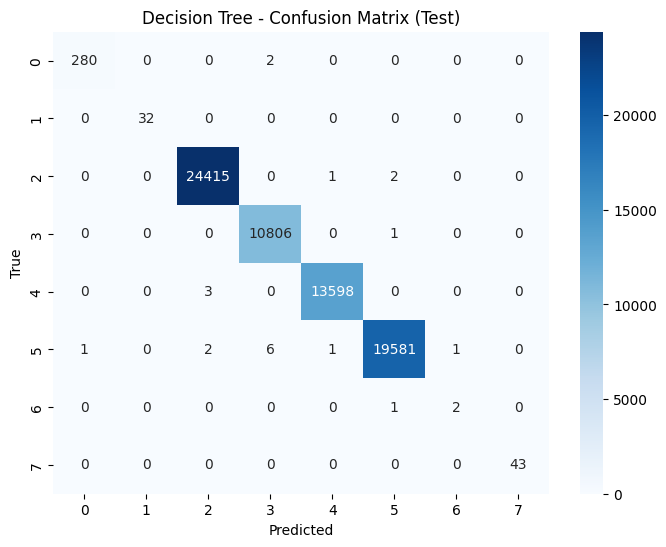

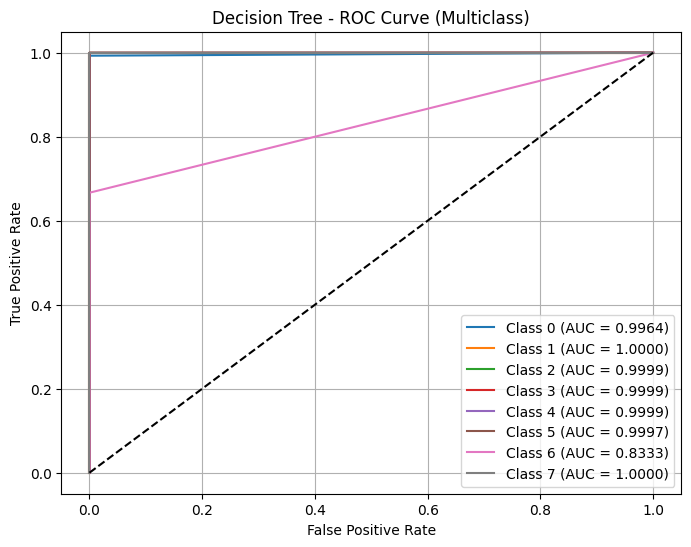

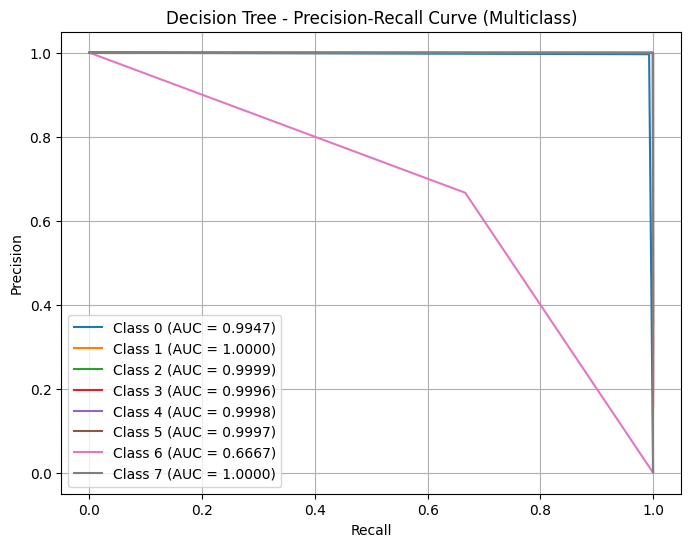

Macro AUC Score:    0.9786
Weighted AUC Score: 0.9998

====== Extra Trees ======
Training Time: 29.47 seconds

Training Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     30000
           1     1.0000    1.0000    1.0000     30000
           2     1.0000    1.0000    1.0000     30000
           3     1.0000    1.0000    1.0000     30000
           4     1.0000    1.0000    1.0000     30000
           5     1.0000    1.0000    1.0000     30000
           6     1.0000    1.0000    1.0000     30000
           7     1.0000    1.0000    1.0000     30000

    accuracy                         1.0000    240000
   macro avg     1.0000    1.0000    1.0000    240000
weighted avg     1.0000    1.0000    1.0000    240000


Testing Classification Report:
              precision    recall  f1-score   support

           0     0.9930    1.0000    0.9965       282
           1     0.9697    1.0000    0.9846        32
           

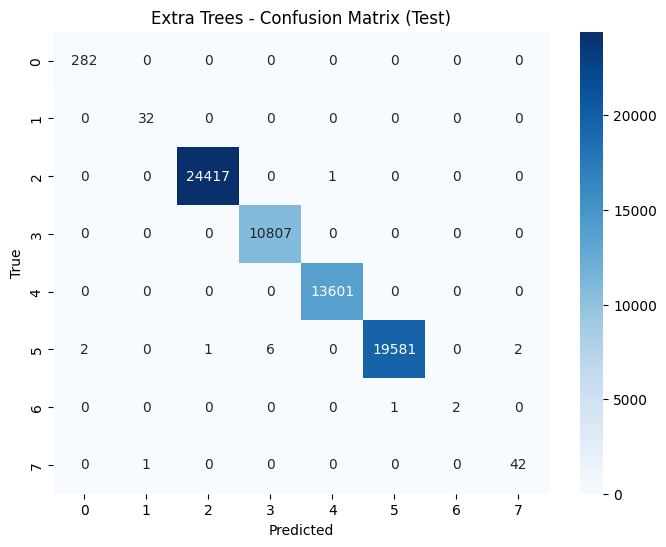

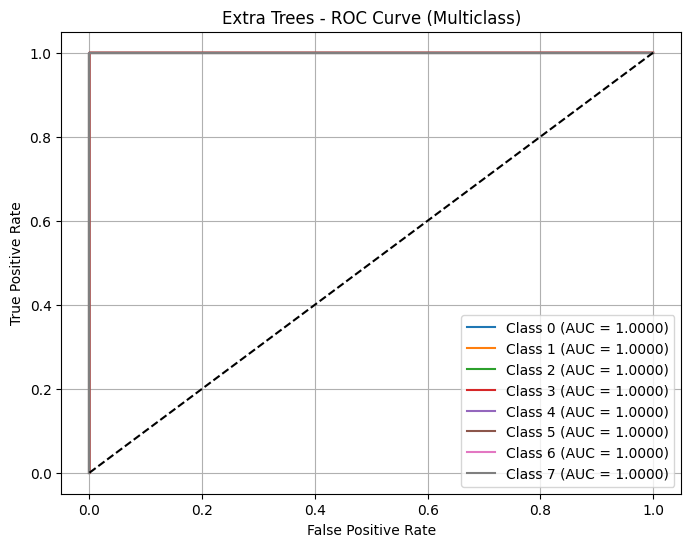

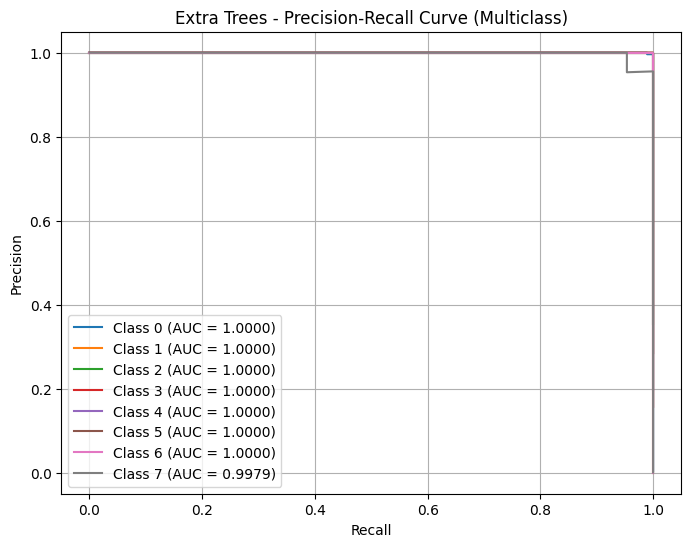

Macro AUC Score:    1.0000
Weighted AUC Score: 1.0000

====== Random Forest ======
Training Time: 32.96 seconds

Training Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     30000
           1     1.0000    1.0000    1.0000     30000
           2     1.0000    1.0000    1.0000     30000
           3     1.0000    1.0000    1.0000     30000
           4     1.0000    1.0000    1.0000     30000
           5     1.0000    1.0000    1.0000     30000
           6     1.0000    1.0000    1.0000     30000
           7     1.0000    1.0000    1.0000     30000

    accuracy                         1.0000    240000
   macro avg     1.0000    1.0000    1.0000    240000
weighted avg     1.0000    1.0000    1.0000    240000


Testing Classification Report:
              precision    recall  f1-score   support

           0     0.9965    1.0000    0.9982       282
           1     1.0000    1.0000    1.0000        32
         

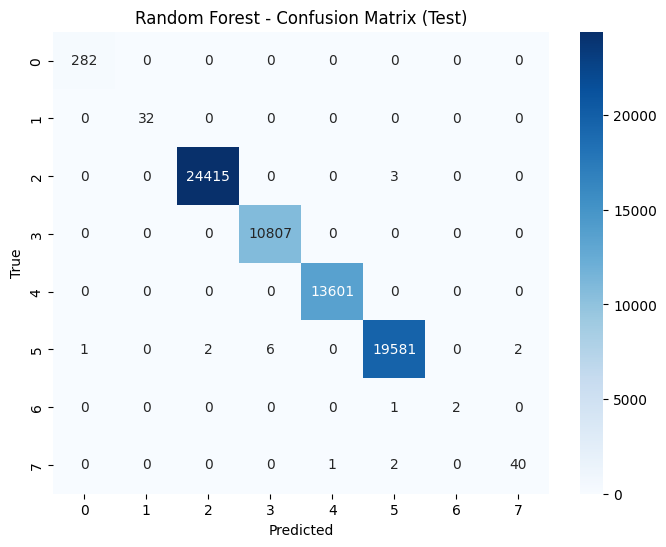

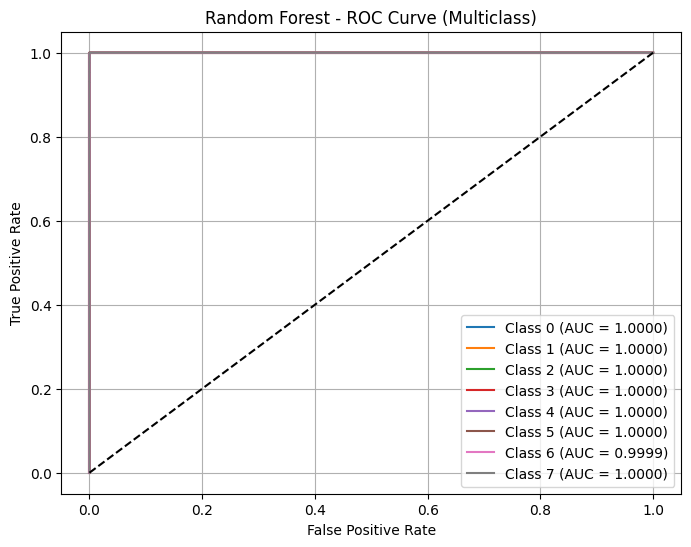

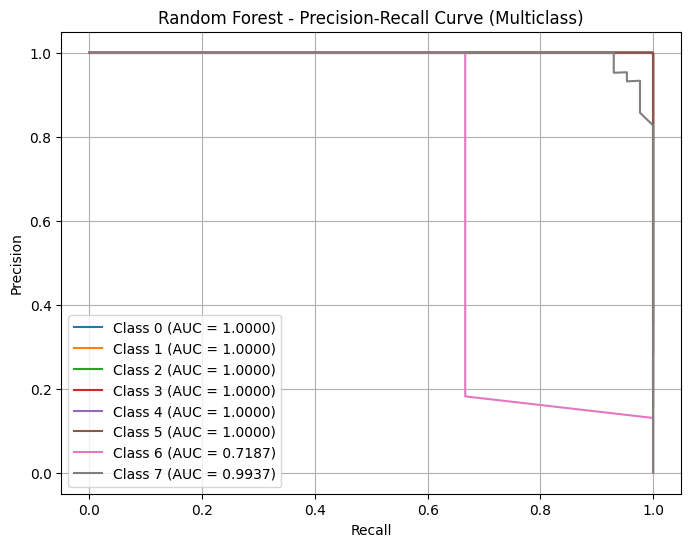

Macro AUC Score:    1.0000
Weighted AUC Score: 1.0000

====== KNN ======
Training Time: 1.12 seconds

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999     30000
           1     1.0000    1.0000    1.0000     30000
           2     0.9998    0.9999    0.9998     30000
           3     0.9992    0.9997    0.9995     30000
           4     0.9999    0.9994    0.9996     30000
           5     0.9997    0.9993    0.9995     30000
           6     1.0000    1.0000    1.0000     30000
           7     1.0000    1.0000    1.0000     30000

    accuracy                         0.9998    240000
   macro avg     0.9998    0.9998    0.9998    240000
weighted avg     0.9998    0.9998    0.9998    240000


Testing Classification Report:
              precision    recall  f1-score   support

           0     0.9758    1.0000    0.9877       282
           1     0.9697    1.0000    0.9846        32
           2     0.9

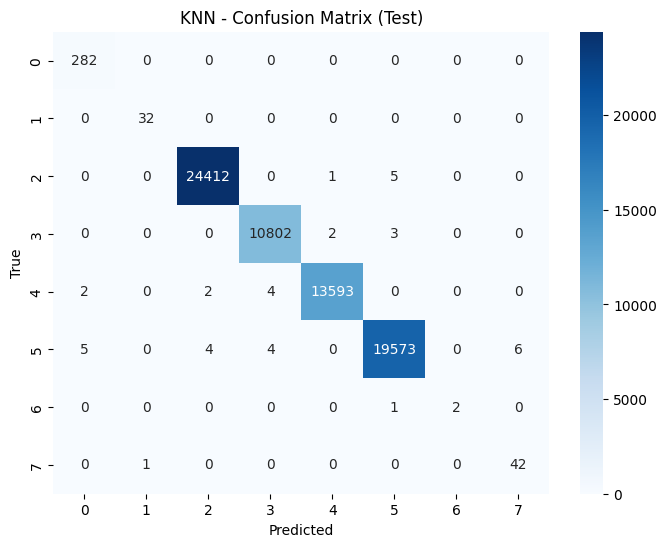

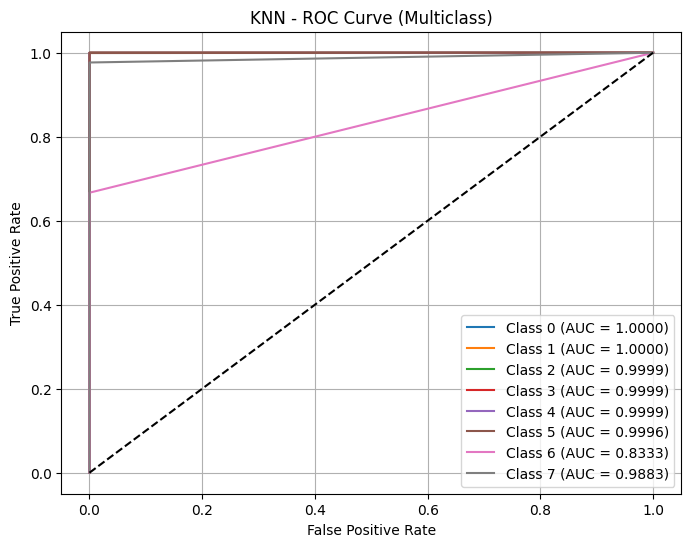

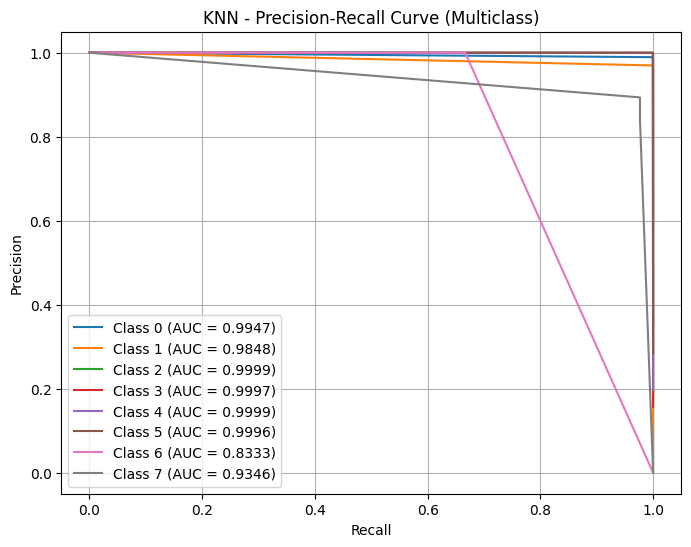

Macro AUC Score:    0.9776
Weighted AUC Score: 0.9998

====== MLP ======
Training Time: 54.58 seconds

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999     30000
           1     1.0000    1.0000    1.0000     30000
           2     1.0000    1.0000    1.0000     30000
           3     0.9995    0.9988    0.9991     30000
           4     0.9999    1.0000    1.0000     30000
           5     0.9988    0.9989    0.9989     30000
           6     1.0000    1.0000    1.0000     30000
           7     0.9997    1.0000    0.9998     30000

    accuracy                         0.9997    240000
   macro avg     0.9997    0.9997    0.9997    240000
weighted avg     0.9997    0.9997    0.9997    240000


Testing Classification Report:
              precision    recall  f1-score   support

           0     0.9792    1.0000    0.9895       282
           1     0.9697    1.0000    0.9846        32
           2     0.

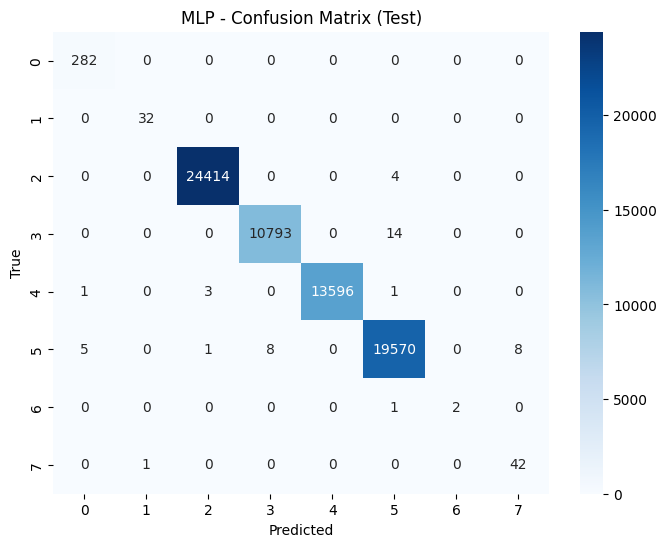

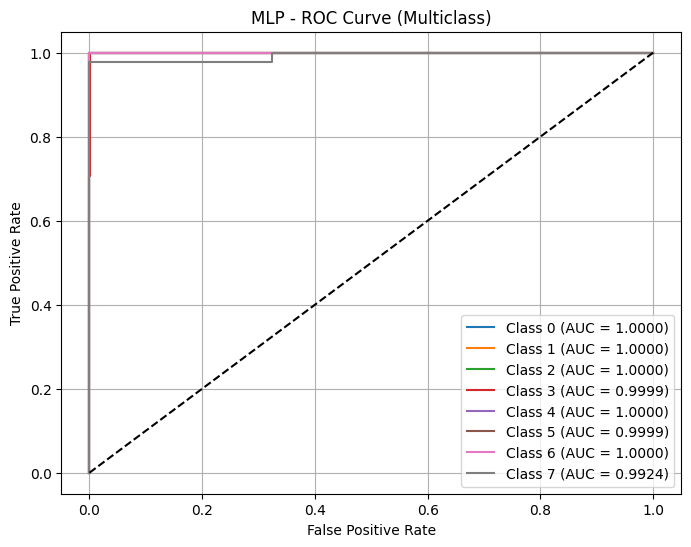

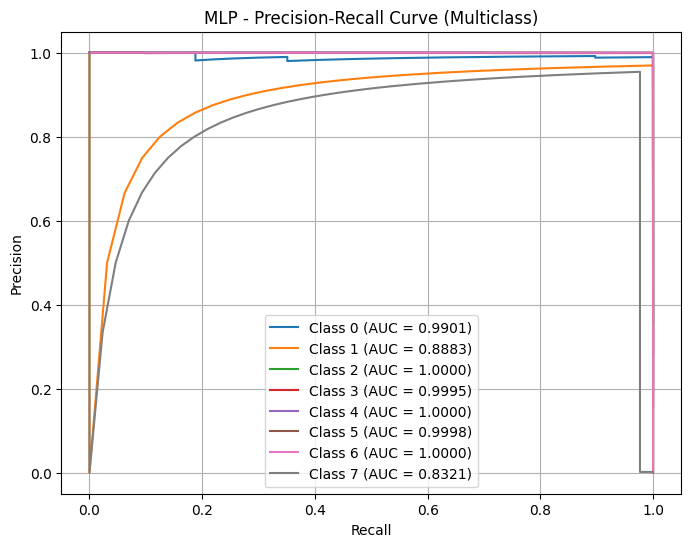

Macro AUC Score:    0.9990
Weighted AUC Score: 0.9999

====== XGBoost ======


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:42:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training Time: 17.58 seconds

Training Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     30000
           1     1.0000    1.0000    1.0000     30000
           2     1.0000    1.0000    1.0000     30000
           3     1.0000    1.0000    1.0000     30000
           4     1.0000    1.0000    1.0000     30000
           5     1.0000    1.0000    1.0000     30000
           6     1.0000    1.0000    1.0000     30000
           7     1.0000    1.0000    1.0000     30000

    accuracy                         1.0000    240000
   macro avg     1.0000    1.0000    1.0000    240000
weighted avg     1.0000    1.0000    1.0000    240000


Testing Classification Report:
              precision    recall  f1-score   support

           0     0.9965    1.0000    0.9982       282
           1     1.0000    1.0000    1.0000        32
           2     0.9999    1.0000    0.9999     24418
           3     0.9996    0.9998    0

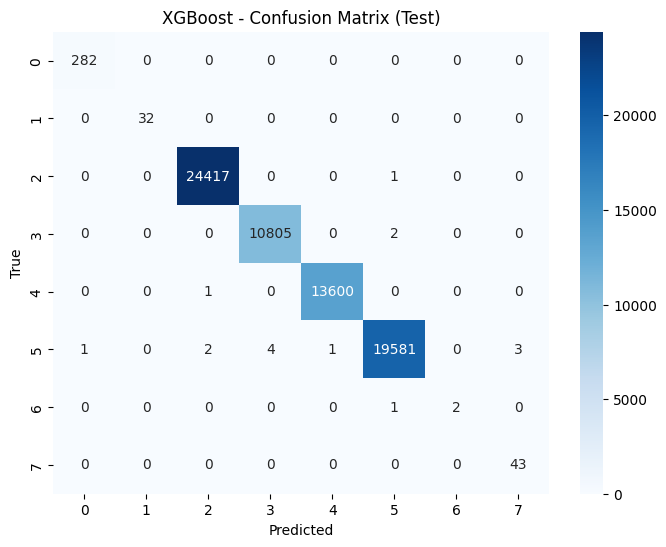

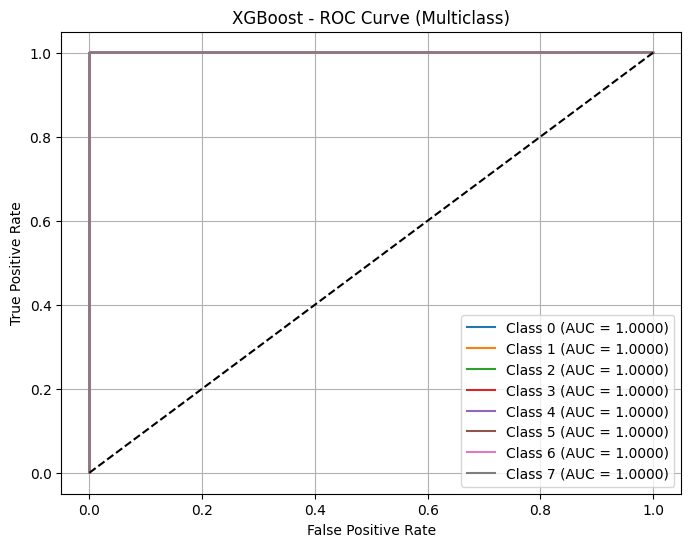

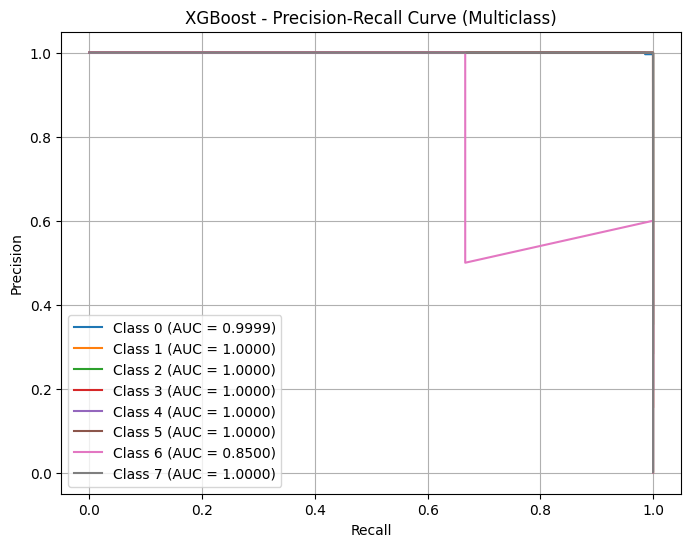

Macro AUC Score:    1.0000
Weighted AUC Score: 1.0000


In [23]:
import pandas as pd
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, cohen_kappa_score, roc_auc_score
)
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import numpy as np
import seaborn as sns

# --- Prepare data ---
X_train = balanced_train_df.drop(columns=['Label'])
y_train = balanced_train_df['Label']

X_test = test_df.drop(columns=['Label'])
y_test = test_df['Label']

# For ROC & PR (multiclass)
classes = sorted(y_train.unique())
y_test_bin = label_binarize(y_test, classes=classes)
y_train_bin = label_binarize(y_train, classes=classes)

# --- Models ---
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# --- Train and Evaluate ---
for name, model in models.items():
    print(f"\n====== {name} ======")

    # Train
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    training_time = end_time - start_time
    print(f"Training Time: {training_time:.2f} seconds")

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training Classification Report
    print("\nTraining Classification Report:")
    print(classification_report(y_train, y_train_pred, digits=4))

    # Testing Classification Report
    print("\nTesting Classification Report:")
    print(classification_report(y_test, y_test_pred, digits=4))

    # Cohen's Kappa Score
    kappa = cohen_kappa_score(y_test, y_test_pred)
    print(f"Kappa Score: {kappa:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'{name} - Confusion Matrix (Test)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # ROC and PR Curves
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        continue  # Skip AUC/curves if scores not available

    if y_score.shape[1] != len(classes):
        continue  # Skip if shape mismatch

    # ROC Curve
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i, c in enumerate(classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    for i in range(len(classes)):
        plt.plot(fpr[i], tpr[i], label=f"Class {classes[i]} (AUC = {roc_auc[i]:.4f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"{name} - ROC Curve (Multiclass)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

    # Precision-Recall Curve
    precision = dict()
    recall = dict()
    pr_auc = dict()
    for i in range(len(classes)):
        precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        pr_auc[i] = auc(recall[i], precision[i])

    plt.figure(figsize=(8, 6))
    for i in range(len(classes)):
        plt.plot(recall[i], precision[i], label=f"Class {classes[i]} (AUC = {pr_auc[i]:.4f})")
    plt.title(f"{name} - Precision-Recall Curve (Multiclass)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc='best')
    plt.grid()
    plt.show()

    # Overall AUC Scores
    try:
        auc_macro = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
        auc_weighted = roc_auc_score(y_test_bin, y_score, average='weighted', multi_class='ovr')
        print(f"Macro AUC Score:    {auc_macro:.4f}")
        print(f"Weighted AUC Score: {auc_weighted:.4f}")
    except Exception as e:
        print(f"AUC Calculation Error: {e}")


**5 fold cross validation**


====== Decision Tree - 5-Fold Cross-Validation ======
Validation Time: 15.62 seconds
Fold-wise Accuracy: [0.9998 0.9999 0.9998 0.9998 0.9999]
Mean Accuracy: 0.9998
Standard Deviation: 0.0000


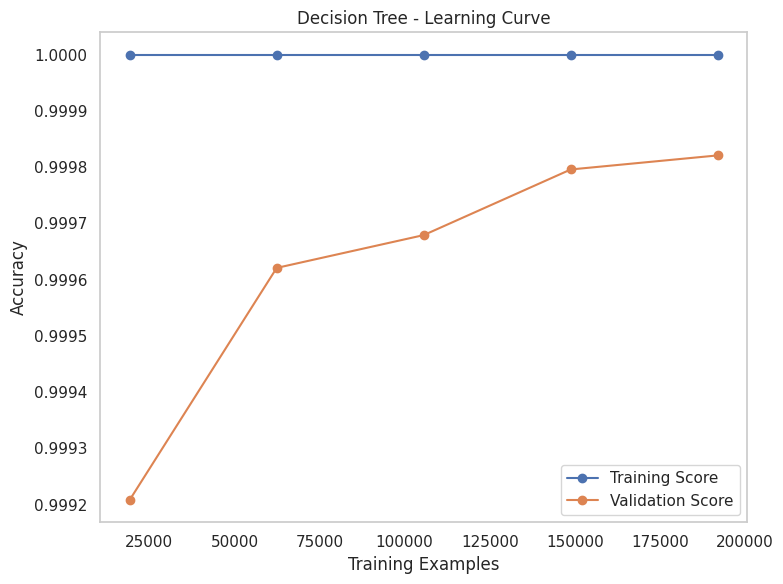


====== Extra Trees - 5-Fold Cross-Validation ======
Validation Time: 54.36 seconds
Fold-wise Accuracy: [1.     1.     0.9999 1.     1.    ]
Mean Accuracy: 1.0000
Standard Deviation: 0.0000


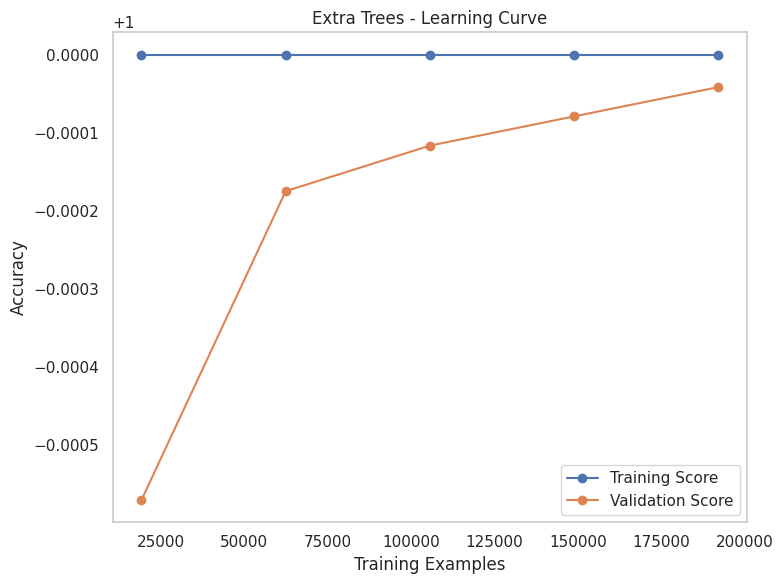


====== Random Forest - 5-Fold Cross-Validation ======
Validation Time: 114.01 seconds
Fold-wise Accuracy: [0.9999 1.     0.9998 0.9999 0.9999]
Mean Accuracy: 0.9999
Standard Deviation: 0.0001


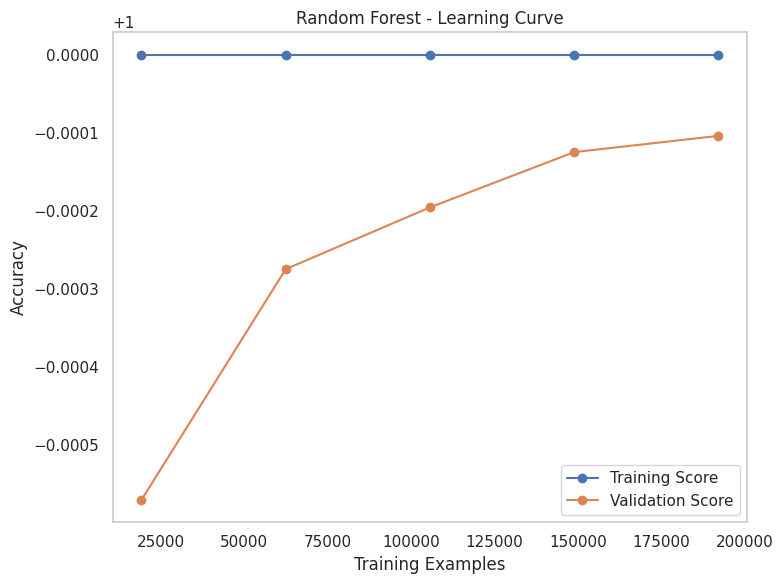


====== KNN - 5-Fold Cross-Validation ======
Validation Time: 45.12 seconds
Fold-wise Accuracy: [0.9995 0.9997 0.9996 0.9997 0.9998]
Mean Accuracy: 0.9997
Standard Deviation: 0.0001


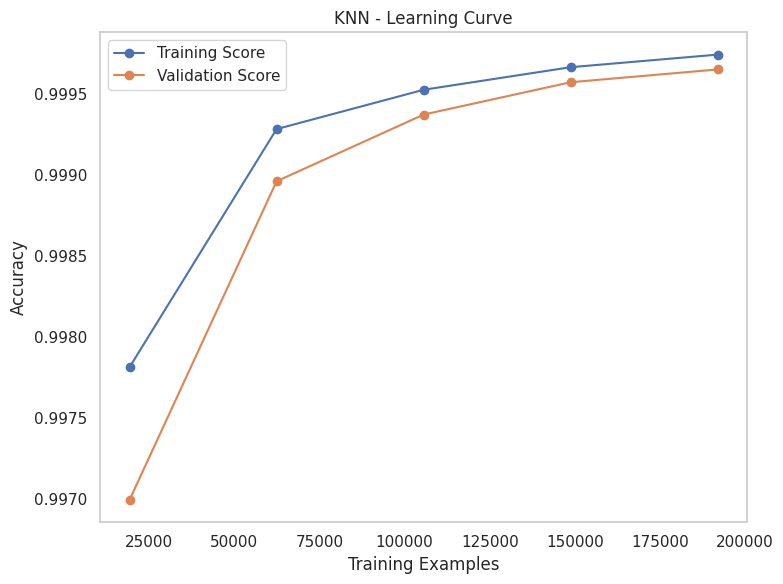


====== MLP - 5-Fold Cross-Validation ======
Validation Time: 199.60 seconds
Fold-wise Accuracy: [0.9996 0.9998 0.9994 0.9996 0.9996]
Mean Accuracy: 0.9996
Standard Deviation: 0.0001


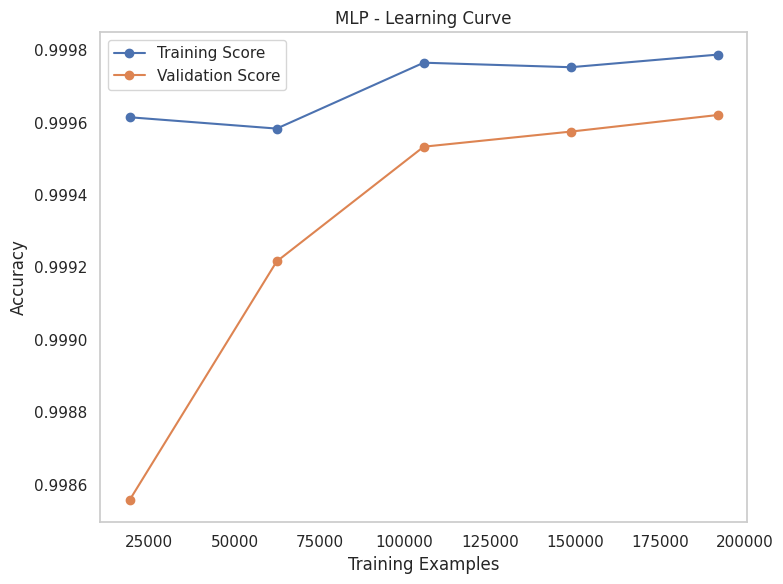


====== XGBoost - 5-Fold Cross-Validation ======
Validation Time: 69.13 seconds
Fold-wise Accuracy: [1.     1.     0.9999 0.9999 1.    ]
Mean Accuracy: 0.9999
Standard Deviation: 0.0000


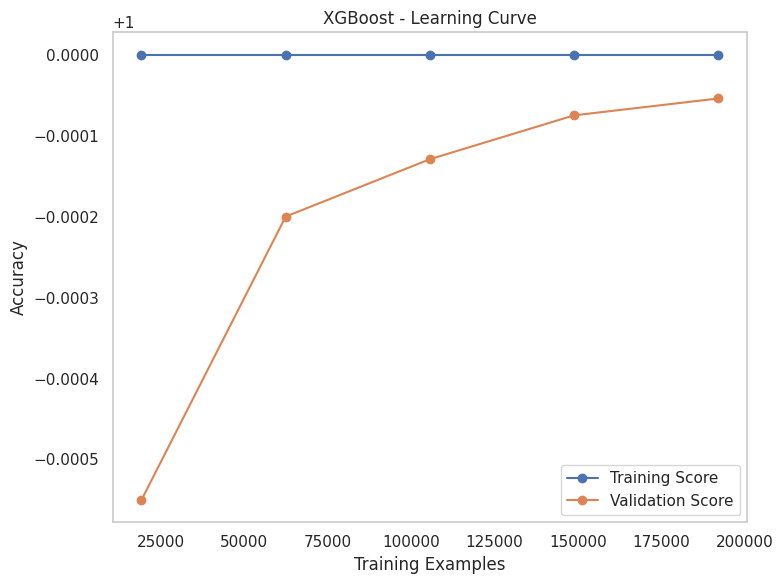

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# --- Prepare data ---
X = balanced_train_df.drop(columns=['Label'])
y = balanced_train_df['Label']

# --- Models ---
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# --- Cross-Validation ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n====== {name} - 5-Fold Cross-Validation ======")

    start_time = time.time()
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
    end_time = time.time()

    print(f"Validation Time: {end_time - start_time:.2f} seconds")
    print(f"Fold-wise Accuracy: {np.round(scores, 4)}")
    print(f"Mean Accuracy: {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")

    # Learning Curve
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=skf, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
    plt.plot(train_sizes, test_mean, 'o-', label='Validation Score')
    plt.title(f"{name} - Learning Curve")
    plt.xlabel("Training Examples")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


In [24]:
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef


**stacking ensemble model with meta learner**


====== Stacking Classifier (DT + ET + MLP -> LGBM) ======


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044855 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5606
[LightGBM] [Info] Number of data points in the train set: 240000, number of used features: 39
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Training Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     30000
           1     1.0000    1.0000    1.0000     30000
           2     1.0000    1.0000    1.0000     30000
           3     1.0000    1.0000    1.0000     30000
           4     1.0000    1.0000    1.0000     30000
           5     1.0000    1.0000    1.0000     30000
           6     1.0000    1.0000    1.0000     30000
           7     1.0000    1.0000    1.0000     30000

    accuracy                         1.0000    240000
   macro avg     1.0000    1.0000    1.0000    240000
weighted avg     1.0000    1.0000    1.0000    240000


Testing Classification Report:
              precision    recall  f1-score   support

           0     0.9965    0.9965    0.9965       282
           1     1.0000    1.0000    1.0000        32
           2     0.9999    1.0000    0.9999     24418
           3     0.9994    0.9999    0.9997     10807
           4 

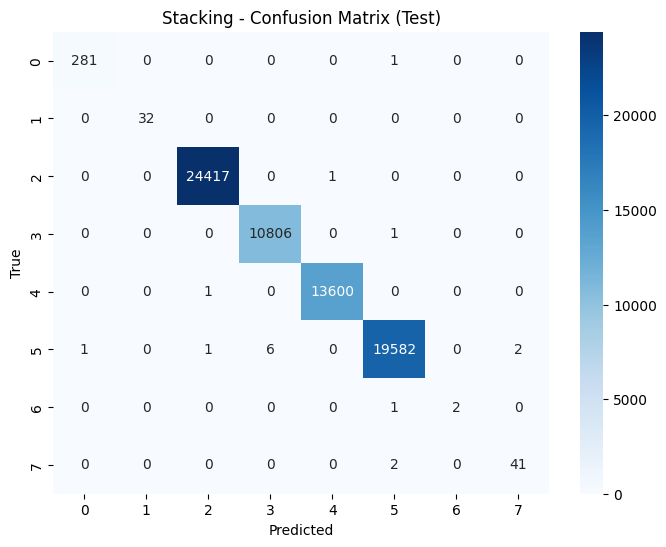

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


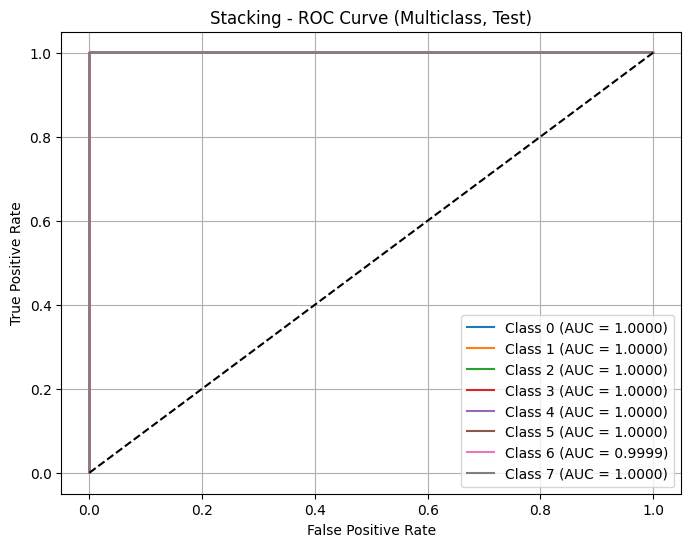

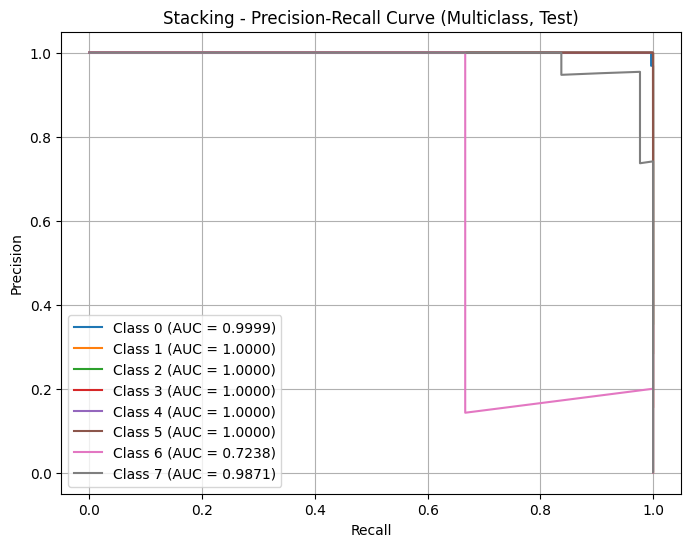

In [25]:
from sklearn.ensemble import StackingClassifier
from lightgbm import LGBMClassifier

# --- Base Learners ---
base_learners = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('et', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42))
]

# --- Meta Learner ---
meta_learner = LGBMClassifier(n_estimators=100, random_state=42)

# --- Stacking Classifier ---
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    passthrough=True,
    n_jobs=-1
)

# --- Train the Stacking Model ---
print("\n====== Stacking Classifier (DT + ET + MLP -> LGBM) ======")
start_time = time.time()
stacking_model.fit(X_train, y_train)
end_time = time.time()
print(f"Training Time: {end_time - start_time:.2f} seconds")

# --- Predictions ---
y_train_pred = stacking_model.predict(X_train)
y_test_pred = stacking_model.predict(X_test)

# --- Reports ---
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred, digits=4))

print("\nTesting Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Stacking - Confusion Matrix (Test)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# --- ROC & PR curves if applicable ---
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=classes)

if hasattr(stacking_model, "predict_proba"):
    y_score = stacking_model.predict_proba(X_test)

    # ROC Curve
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i, c in enumerate(classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    for i in range(len(classes)):
        plt.plot(fpr[i], tpr[i], label=f"Class {classes[i]} (AUC = {roc_auc[i]:.4f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("Stacking - ROC Curve (Multiclass, Test)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

    # PR Curve
    precision = dict()
    recall = dict()
    pr_auc = dict()
    for i in range(len(classes)):
        precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        pr_auc[i] = auc(recall[i], precision[i])

    plt.figure(figsize=(8, 6))
    for i in range(len(classes)):
        plt.plot(recall[i], precision[i], label=f"Class {classes[i]} (AUC = {pr_auc[i]:.4f})")
    plt.title("Stacking - Precision-Recall Curve (Multiclass, Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc='best')
    plt.grid()
    plt.show()


**cross valdiation on stacking model**


====== 5-Fold CV: Stacking Classifier (DT + ET + MLP -> LGBM) ======


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034421 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5618
[LightGBM] [Info] Number of data points in the train set: 192000, number of used features: 39
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 1 Accuracy: 1.0000 | Time: 350.35s


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.140966 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5617
[LightGBM] [Info] Number of data points in the train set: 192000, number of used features: 39
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 5 Accuracy: 1.0000 | Time: 331.43s

Mean Accuracy: 0.9999
Standard Deviation: 0.0000


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


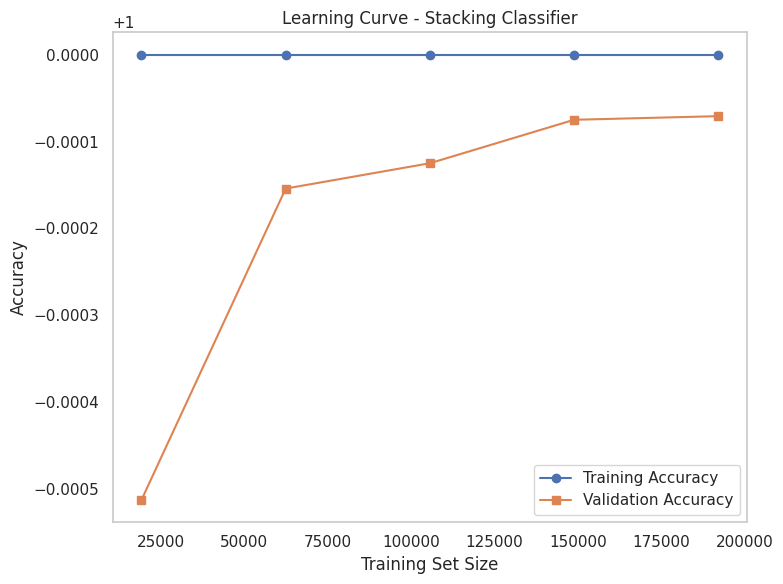

In [39]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.ensemble import StackingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score


# === Base and Meta Learners ===
base_learners = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('et', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42))
]

meta_learner = LGBMClassifier(n_estimators=100, random_state=42)

# === Cross-Validation Setup ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []

print("\n====== 5-Fold CV: Stacking Classifier (DT + ET + MLP -> LGBM) ======")
for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = StackingClassifier(
        estimators=base_learners,
        final_estimator=meta_learner,
        passthrough=True,
        n_jobs=-1
    )

    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    y_val_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f} | Time: {end - start:.2f}s")

# === Overall Results ===
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)
print(f"\nMean Accuracy: {mean_acc:.4f}")
print(f"Standard Deviation: {std_acc:.4f}")

# === Learning Curve ===
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y,
    cv=cv,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', label='Training Accuracy')
plt.plot(train_sizes, val_mean, 's-', label='Validation Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Stacking Classifier')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [27]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d73fa192cba82b441fe0f3505e75f08464247b574e7c58b16d650d8fca3971fd
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


**explaining model decision making using lime explaiable ai**

In [28]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import random

# --- Define classes (0 to 7) ---
classes = [0, 1, 2, 3, 4, 5, 6, 7]

# --- Initialize LIME Explainer ---
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns if hasattr(X_train, 'columns') else [f'Feature {i}' for i in range(X_train.shape[1])],
    class_names=[str(c) for c in classes],
    mode='classification',
    discretize_continuous=True
)

# --- LIME Explanations for Each Class (0 to 7) ---
print("\n====== LIME Explanations (Class 0 to 7) ======")

for target_class in classes:
    print(f"\n🔍 LIME Explanation for Class {target_class}")

    # Find test sample index for the current class
    idx_list = np.where(y_test == target_class)[0]
    if len(idx_list) == 0:
        print(f"No sample found for class {target_class} in test set.")
        continue

    idx = random.choice(idx_list)

    # Extract instance
    if isinstance(X_test, np.ndarray):
        instance = X_test[idx]
    else:
        instance = X_test.iloc[idx].values

    # Generate LIME explanation
    exp = explainer.explain_instance(
        data_row=instance,
        predict_fn=stacking_model.predict_proba,
        num_features=10,
        top_labels=1
    )

    # Show in notebook
    exp.show_in_notebook(show_table=True, show_all=False)

    # Save to HTML
    html_file = f"lime_class_{target_class}.html"
    exp.save_to_file(html_file)
    print(f"LIME explanation saved to {html_file}")



====== LIME Explanations (Class 0 to 7) ======

🔍 LIME Explanation for Class 0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LIME explanation saved to lime_class_0.html

🔍 LIME Explanation for Class 1


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LIME explanation saved to lime_class_1.html

🔍 LIME Explanation for Class 2


...

LIME explanation saved to lime_class_5.html

🔍 LIME Explanation for Class 6


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LIME explanation saved to lime_class_6.html

🔍 LIME Explanation for Class 7


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LIME explanation saved to lime_class_7.html


**train of lr and mlp**

**train of rf dt knn**